# 06 — Deep Learning
**Objetivo:** Predecir consumo energético 24 horas adelante usando una red neuronal MLP.  
**Dataset:** PJME Hourly Energy Consumption  


## 0. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
import sys

sys.path.append('../src')

from modeling.DL_MLP import (
    build_model,
    get_dataloaders,
    train_model,
    evaluate_model,
    save_model,
    load_model,
    set_seed,
    DEVICE
)
set_seed(22)

from utils.metrics import calculate_metrics, print_metrics

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")

FH         = 24
TARGET_COL = 'PJME_MW'

Semilla fijada: 22
PyTorch version : 2.10.0+cpu
Device          : cpu


## 1. Cargar datos

In [2]:
data_dir = Path('../data/processed')

train_df = pd.read_csv(data_dir / f'train_{FH}hr.csv', index_col='Datetime', parse_dates=True)
val_df   = pd.read_csv(data_dir / f'val_{FH}hr.csv',   index_col='Datetime', parse_dates=True)
test_df  = pd.read_csv(data_dir / f'test_{FH}hr.csv',  index_col='Datetime', parse_dates=True)

train_df = train_df.asfreq('h')
val_df   = val_df.asfreq('h')
test_df  = test_df.asfreq('h')

print(f"Train : {train_df.shape}  {train_df.index[0].date()} → {train_df.index[-1].date()}")
print(f"Val   : {val_df.shape}    {val_df.index[0].date()} → {val_df.index[-1].date()}")
print(f"Test  : {test_df.shape}   {test_df.index[0].date()} → {test_df.index[-1].date()}")

Train : (101622, 50)  2002-01-09 → 2013-08-13
Val   : (21752, 50)    2013-08-14 → 2016-02-06
Test  : (21753, 50)   2016-02-07 → 2018-08-02


## 2. DataLoaders + Scaler

In [3]:
train_loader, val_loader, test_loader, scaler_y, feature_cols = get_dataloaders(
    train_df, val_df, test_df,
    target_col = TARGET_COL,
    batch_size = 128,
)

print(f"\nFeatures usadas ({len(feature_cols)}):")
print(feature_cols)

Input size (n_features): 49
Train batches: 794 | Val batches: 170 | Test batches: 170

Features usadas (49):
['hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'weekofyear', 'is_weekend', 'is_month_start', 'is_month_end', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos', 'is_holiday', 'near_holiday', 'lag_24', 'lag_25', 'lag_26', 'lag_47', 'lag_48', 'lag_168', 'lag_169', 'rolling_mean_24', 'rolling_std_24', 'rolling_min_24', 'rolling_max_24', 'rolling_mean_168', 'rolling_std_168', 'rolling_min_168', 'rolling_max_168', 'diff_24h', 'diff_168h', 'pct_change_24h', 'pct_change_168h', 'volatility_std_24', 'volatility_std_168', 'volatility_cv_24', 'volatility_cv_168', 'volatility_range_24', 'volatility_range_168', 'change_1h', 'volatility_changes_24', 'volatility_changes_168', 'volatility_iqr_24', 'volatility_iqr_168', 'expanding_mean']


## 3. Construir modelo

In [4]:
model = build_model(
    train_loader,
    hidden_sizes = [128, 64, 32],
    dropout      = 0.2,
)

Arquitectura: 49 → [128, 64, 32] → 1
Parámetros totales: 17,217
Device: cpu


## 4. Entrenamiento

In [5]:
# history = train_model(
#     model,
#     train_loader,
#     val_loader,
#     epochs    = 50,
#     lr        = 1e-3,
#     patience  = 10,
#     save_path = '../models/dl_best_mlp.pt',
# )

## 4.1. Cargar modelo


In [6]:
# # Cargar modelo guardado (comentar bloque build_model si se usa esto)
model, scaler_y, feature_cols, history = load_model('../models/dl_mlp.pt')

Modelo cargado desde ../models/dl_mlp.pt


### Curva de entrenamiento

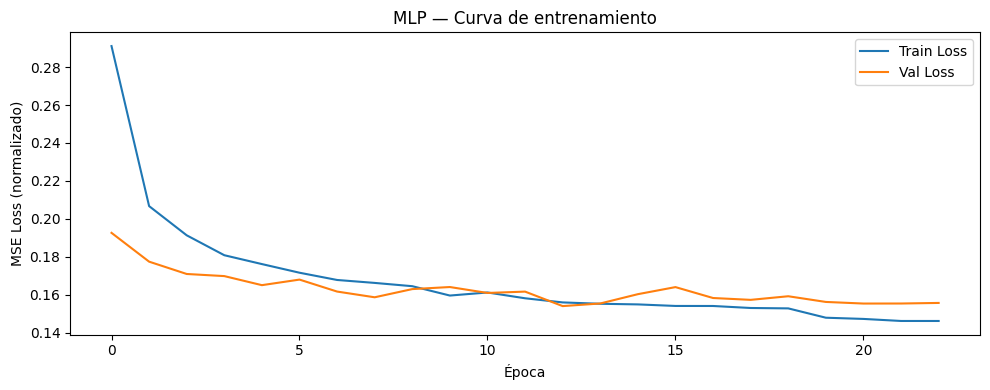

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train_loss'], label='Train Loss')
ax.plot(history['val_loss'],   label='Val Loss')
ax.set_xlabel('Época')
ax.set_ylabel('MSE Loss (normalizado)')
ax.set_title('MLP — Curva de entrenamiento')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/dl_mlp_training_curve.png', dpi=150)
plt.show()

## 5. Evaluación

In [8]:
# Cargar el mejor checkpoint guardado durante el entrenamiento
model.load_state_dict(torch.load('../models/dl_best_mlp.pt', map_location=DEVICE))

metrics_val,  y_true_val,  y_pred_val  = evaluate_model(model, val_loader,  scaler_y, set_name='Val')
metrics_test, y_true_test, y_pred_test = evaluate_model(model, test_loader, scaler_y, set_name='Test')


Métricas - Val
Mean_True:  31,496.88 MW
Std_True: 6,184.08 MW
MAE:  1,884.84 MW
RMSE: 2,552.69 MW
MAPE: 5.85%
R²:   0.8296


Métricas - Test
Mean_True:  31,101.32 MW
Std_True: 6,446.02 MW
MAE:  2,081.28 MW
RMSE: 2,804.63 MW
MAPE: 6.53%
R²:   0.8107



### Predicciones vs Real

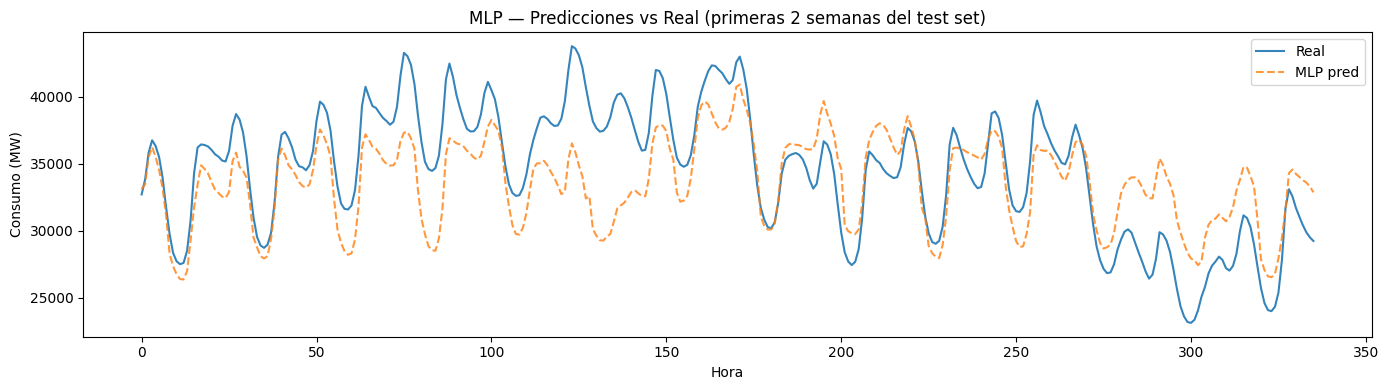

In [9]:
N = 24 * 14  # 2 semanas

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_true_test[:N], label='Real',     alpha=0.9)
ax.plot(y_pred_test[:N], label='MLP pred', alpha=0.8, linestyle='--')
ax.set_xlabel('Hora')
ax.set_ylabel('Consumo (MW)')
ax.set_title('MLP — Predicciones vs Real (primeras 2 semanas del test set)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/dl_mlp_predictions.png', dpi=150)
plt.show()

## 6. Guardar modelo y resultados

In [10]:
save_model(model, scaler_y, feature_cols, history=history, path='../models/dl_mlp.pt')

# Agregar a tabla de resultados comparativa
metrics_test['model'] = 'MLP'
print(metrics_test)

results_df = pd.DataFrame([metrics_test])
results_df.to_csv('../reports/metrics/dl_mlp_metrics.csv', index=False)

Modelo guardado en ../models/dl_mlp.pt
{'Mean_True': np.float32(31101.322), 'Std_True': np.float32(6446.025), 'MAE': 2081.275390625, 'RMSE': np.float64(2804.634468161582), 'MAPE': np.float32(6.534469), 'R2': 0.8106921911239624, 'set': 'Test', 'model': 'MLP'}
